# **T3A** Intensidade da Luz

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.odr import RealData, Model, ODR
import sys
sys.path.append("../..")
import base as b

In [9]:
Vds,ds,Vf1,x1,Vf2,x2,Vf3,x3 = b.getData("export.txt")
dDB = 0.4 # distancia detetor-base
dF0 = 9 #distanci fonte-0
d2 = 1/(ds+dDB-dF0)**2
ud2 = 0.4/(ds+dDB-dF0)**3
print(Vf1)

[451. 268.  nan  nan  nan  nan  nan  nan  nan  nan  nan  nan  nan  nan
  nan  nan  nan  nan  nan  nan]


In [10]:
#uV=np.array([0.2261,0.2294,0.2345,0.2405,0.2468,0.2582,0.272,0.2894,0.3233,0.3689,0.4481,0.5792,0.9137,1.847,3.731,1.253,0.6743,2.522,3.008,4.652])
uV=np.array([0.4, 0.4, 0.4, 0.4, 0.4 ,0.5, 0.5, 0.5, 0.6, 0.8, 1.0, 1.3 ,2.2, 5 ,10 ,3, 1.6, 6, 8, 12])

## Distâncias

Beta: [1.59111040e+00 4.64303037e-04]
Beta Std Error: [6.92230011e-03 8.13042503e-05]
Beta Covariance: [[ 3.69760359e-05 -3.53618076e-07]
 [-3.53618076e-07  5.10089052e-09]]
Residual Variance: 1.2959268788599407
Inverse Condition #: 0.0067992101010246955
Reason(s) for Halting:
  Sum of squares convergence


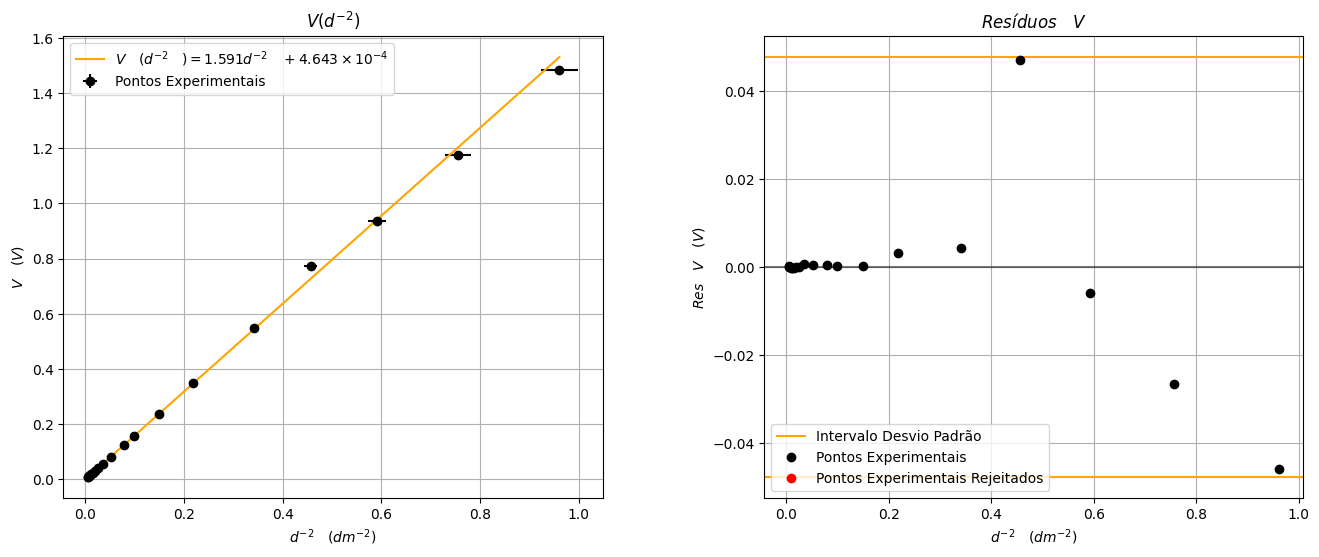

In [11]:
adjust = b.plotColumnFullLinReg([d2/.01],[Vds*.001],[ud2/.01],[0.1*.001],["V (d^{-2})"],["d^{-2}\\quad(dm^{-2})"],["V\\quad(V)"],tol=3)
adjust[0].pprint()

## Filtros

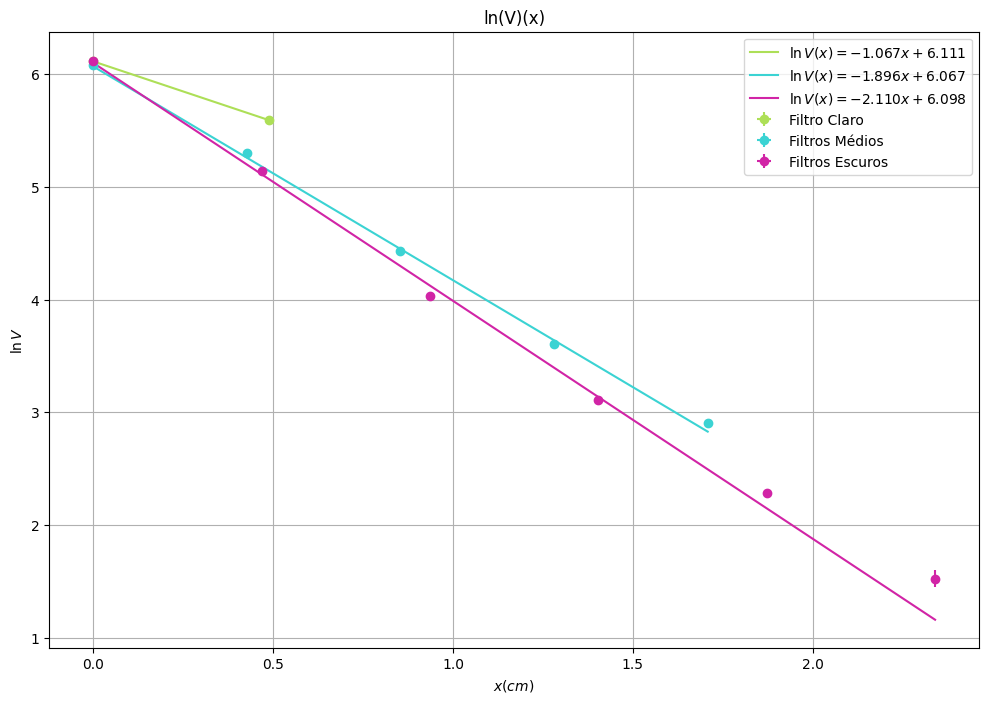

Beta: [-1.06655811  6.11146734]
Beta Std Error: [2.01657967e-30 5.98760511e-31]
Beta Covariance: [[ 0.00248668 -0.00044924]
 [-0.00044924  0.00021923]]
Residual Variance: 1.6353488224980776e-57
Inverse Condition #: 0.23024026933347191
Reason(s) for Halting:
  Parameter convergence
Beta: [-1.89552353  6.06684351]
Beta Std Error: [0.03669157 0.03495933]
Beta Covariance: [[ 0.00022041 -0.00017198]
 [-0.00017198  0.00020009]]
Residual Variance: 6.107902293111599
Inverse Condition #: 0.2764774057203318
Reason(s) for Halting:
  Sum of squares convergence
Beta: [-2.10960837  6.09815977]
Beta Std Error: [0.0596027  0.04868849]
Beta Covariance: [[ 0.00019279 -0.00011371]
 [-0.00011371  0.00012865]]
Residual Variance: 18.426557523954457
Inverse Condition #: 0.37041345021421074
Reason(s) for Halting:
  Sum of squares convergence


In [12]:
xs = [x1,x2,x3]
ys = [np.log(Vf1),np.log(Vf2),np.log(Vf3)]
xerrs = [.002,.004,.005]

uc,um,ue=np.genfromtxt('unfiltros.txt',unpack=True)
yerrs = [uc[:2],um[:5],ue]
legends=["Filtro Claro", "Filtros Médios", "Filtros Escuros"]

regs = b.plotMultipleReg(xs,ys,xerrs,yerrs,"ln(V)(x)","x(cm)",r"\ln{V}",["#ADDF57","#3BD3D3","#D124A6",],legends)

for i in regs:
    i.pprint()


In [13]:
def ualhpa(dec,lnV0,udec,ulnV0=0.1):
    return np.sqrt((1/lnV0*udec)**2+(dec/lnV0**2*ulnV0)**2)

for i in range(0,len(regs)):
    dec = regs[i].beta[0]
    udec = regs[i].sd_beta[0]

    print(f"α = ({-dec:.3f} ± {udec:.3f})")

α = (1.067 ± 0.000)
α = (1.896 ± 0.037)
α = (2.110 ± 0.060)


In [14]:
uc,um,ue=np.genfromtxt('unfiltros.txt',unpack=True)
um[:5]

array([0.01489655, 0.023     , 0.01158852, 0.01615217, 0.02439344])